# 📊 Comparaison Finale — LSTM vs BiLSTM vs CNN
**Prérequis :** Avoir exécuté les 3 notebooks précédents qui ont sauvegardé dans Drive :
- `metrics_lstm.csv`, `metrics_bilstm.csv`, `metrics_cnn.csv`
- `best_lstm.keras`, `best_bilstm.keras`, `best_cnn.keras`

> Ce notebook charge les modèles entraînés, recalcule toutes les métriques et génère les visualisations de comparaison.

## 1. 📦 Imports & Configuration

In [2]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    f1_score, precision_score, recall_score,
    confusion_matrix
)

#parametres 
MAX_FEATURES = 30000
MAX_LEN = 200

# Style global
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {'LSTM': '#4299e1', 'BiLSTM': '#e53e3e', 'CNN': '#48bb78'}
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print(f'TensorFlow : {tf.__version__}')
print(f'GPU         : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
GPU         : []


## 2. 🔗 Connexion Drive & Chargement des données

In [3]:
import gdown

# Téléchargement des données (mêmes IDs que les notebooks 01/02/03)
gdown.download('https://drive.google.com/uc?id=1Z2zgdnGuD61vJ0QtfPGlvmjvM6x1LHUq', 'train.csv', quiet=False)
gdown.download('https://drive.google.com/uc?id=1uDzllIpQ-08vlNlG21k5xVk2WdrOeTVz', 'test.csv', quiet=False)

RESULTS_DIR = 'results'  # même dossier que les notebooks précédents
os.makedirs(RESULTS_DIR, exist_ok=True)

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')
print(f'Train : {train_df.shape} | Test : {test_df.shape}')

Mounted at /content/drive
Train : (159571, 8) | Test : (153164, 2)


## 3. 🧹 Preprocessing (identique aux notebooks modèles)

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    text = re.sub(r'[^a-z0-9\s!?.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['comment_text'].apply(clean_text)
test_df['clean_text']  = test_df['comment_text'].apply(clean_text)

tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

X_all = pad_sequences(
    tokenizer.texts_to_sequences(train_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y_all = train_df[LABELS].values

# MÊME seed que les notebooks précédents → même split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=VAL_SPLIT, random_state=42, stratify=y_all[:, 0]
)
print(f'Validation set : {X_val.shape[0]:,} exemples')

Validation set : 15,958 exemples


## 4. 📥 Chargement des modèles entraînés

In [5]:
class AttentionLayer(Layer):
    """Couche d'attention compatible Keras 3 (TF 2.16+)."""

    def build(self, input_shape):
        # ← name= en keyword, pas positionnel
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            name='attention_weight',
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            name='attention_bias',
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(x * a, axis=1)

    def get_config(self):
        # Nécessaire pour la sérialisation Keras 3
        return super().get_config()


custom_objects = {'AttentionLayer': AttentionLayer}

print('Chargement des modèles...')

RESULTS_DIR = 'results'  # même dossier local que les notebooks précédents
models = {
    'LSTM':   load_model(os.path.join(RESULTS_DIR, 'best_lstm.keras')),
    'BiLSTM': load_model(os.path.join(RESULTS_DIR, 'best_bilstm.keras'),
                         custom_objects=custom_objects),
    'CNN':    load_model(os.path.join(RESULTS_DIR, 'best_cnn.keras')),
}
for name, model in models.items():
    print(f'  {name:8s} : {model.count_params():>10,} paramètres')

Chargement des modèles...
  LSTM     :  3,904,454 paramètres
  BiLSTM   :  4,013,774 paramètres
  CNN      :  4,237,062 paramètres


## 5. 📊 Calcul de toutes les métriques

In [6]:
def full_evaluation(models_dict, X_val, y_val, threshold=0.5):
    """Évalue tous les modèles et retourne un DataFrame de comparaison."""
    summary = []
    predictions = {}

    for name, model in models_dict.items():
        print(f'\n  Évaluation {name}...')
        t0 = time.time()
        y_proba = model.predict(X_val, batch_size=512, verbose=0)
        latency = (time.time() - t0) * 1000 / len(X_val)  # ms par exemple

        y_pred = (y_proba >= threshold).astype(int)
        predictions[name] = {'proba': y_proba, 'pred': y_pred}

        row = {
            'Modèle':           name,
            'ROC-AUC':          round(roc_auc_score(y_val, y_proba, average='macro'), 4),
            'F1 macro':         round(f1_score(y_val, y_pred, average='macro',    zero_division=0), 4),
            'F1 micro':         round(f1_score(y_val, y_pred, average='micro',    zero_division=0), 4),
            'F1 weighted':      round(f1_score(y_val, y_pred, average='weighted', zero_division=0), 4),
            'Précision macro':  round(precision_score(y_val, y_pred, average='macro', zero_division=0), 4),
            'Recall macro':     round(recall_score(y_val, y_pred, average='macro',    zero_division=0), 4),
            'Latence (ms/ex)':  round(latency, 3),
            'Paramètres':       model.count_params(),
        }
        summary.append(row)

        # AUC par label
        row['auc_per_label'] = {
            label: round(roc_auc_score(y_val[:, i], y_proba[:, i]), 4)
            for i, label in enumerate(LABELS)
        }

    df = pd.DataFrame(summary).set_index('Modèle')
    return df, predictions

print('=== Évaluation complète ===')
df_results, preds = full_evaluation(models, X_val, y_val)

# Affichage formaté
display_cols = ['ROC-AUC', 'F1 macro', 'F1 micro', 'F1 weighted', 'Précision macro', 'Recall macro', 'Latence (ms/ex)']
print('\n' + '='*65)
print('  TABLEAU COMPARATIF FINAL')
print('='*65)
print(df_results[display_cols].to_string())

=== Évaluation complète ===

  Évaluation LSTM...

  Évaluation BiLSTM...

  Évaluation CNN...

  TABLEAU COMPARATIF FINAL
        ROC-AUC  F1 macro  F1 micro  F1 weighted  Précision macro  Recall macro  Latence (ms/ex)
Modèle                                                                                          
LSTM     0.9741    0.3799    0.7245       0.6913           0.4080        0.3556            1.376
BiLSTM   0.9771    0.4068    0.7410       0.7100           0.4854        0.3774            3.445
CNN      0.9755    0.4596    0.7506       0.7251           0.6275        0.4388            5.139


## 6. 🎨 Visualisation 1 — Tableau comparatif visuel

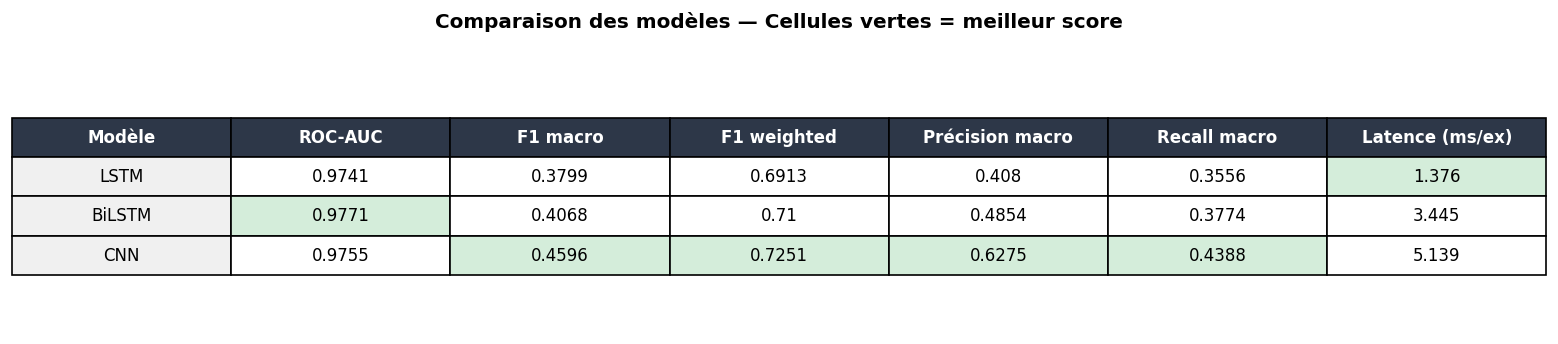

In [7]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')

metrics_show = ['ROC-AUC', 'F1 macro', 'F1 weighted', 'Précision macro', 'Recall macro', 'Latence (ms/ex)']
table_data = df_results[metrics_show].reset_index()

# Trouver le meilleur index par colonne
col_best = []
for col in metrics_show:
    vals = table_data[col].tolist()
    best_idx = vals.index(min(vals)) if col == 'Latence (ms/ex)' else vals.index(max(vals))
    col_best.append(best_idx)

cell_text = []
for _, row in table_data.iterrows():
    cell_text.append([str(row['Modèle'])] + [str(row[c]) for c in metrics_show])

table = ax.table(
    cellText=cell_text,
    colLabels=['Modèle'] + metrics_show,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# ── Colorier manuellement après création ──────────────────────
n_rows = len(cell_text)
n_cols = len(metrics_show) + 1

for row_idx in range(n_rows + 1):
    for col_idx in range(n_cols):
        cell = table[row_idx, col_idx]

        if row_idx == 0:
            # Entête
            cell.set_facecolor('#2d3748')
            cell.set_text_props(color='white', fontweight='bold')
        elif col_idx == 0:
            # Colonne Modèle
            cell.set_facecolor('#f0f0f0')
        else:
            # Meilleure valeur de la colonne → vert
            metric_col_idx = col_idx - 1
            if row_idx - 1 == col_best[metric_col_idx]:
                cell.set_facecolor('#d4edda')
            else:
                cell.set_facecolor('white')

plt.title('Comparaison des modèles — Cellules vertes = meilleur score',
          pad=20, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_table.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. 🎨 Visualisation 2 — ROC-AUC par label

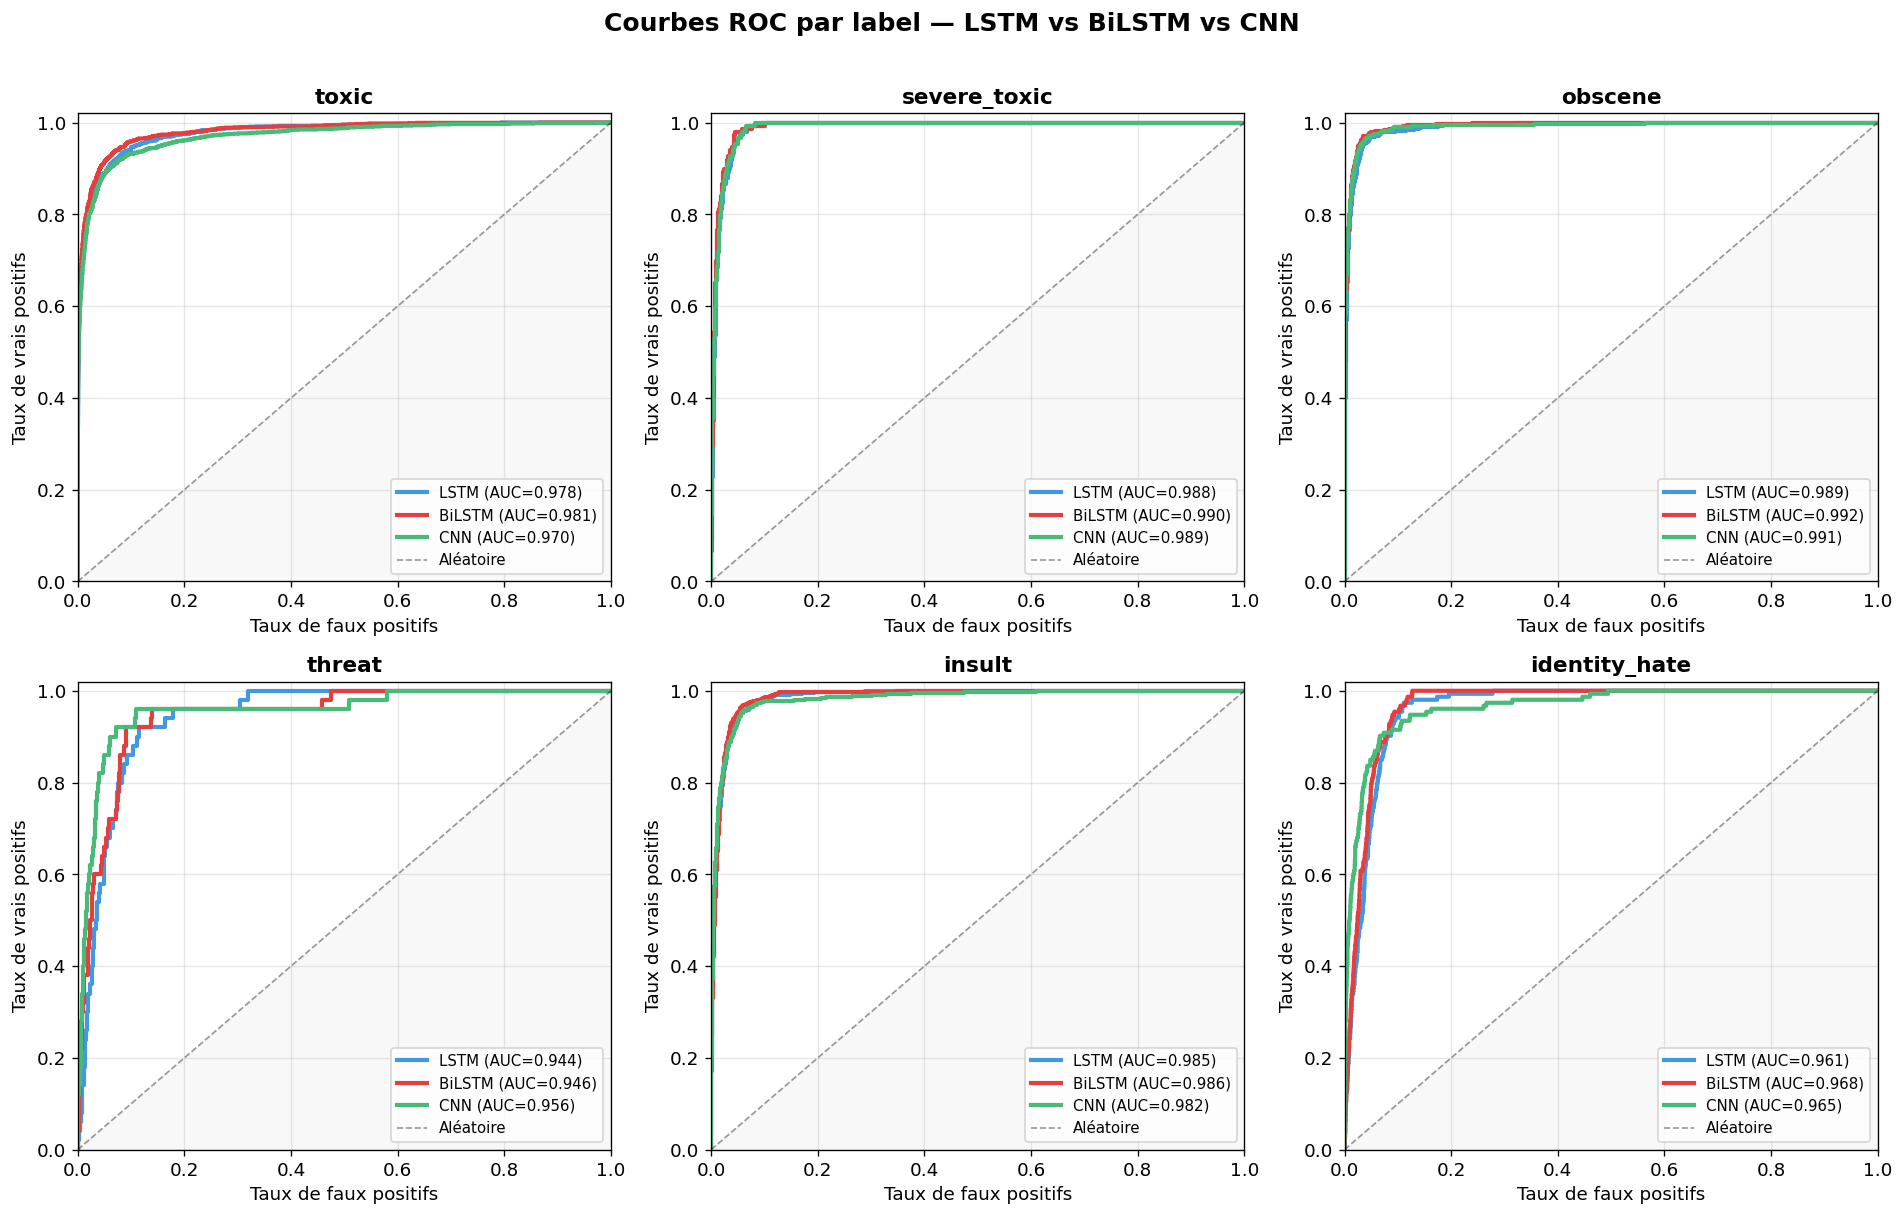

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, label in enumerate(LABELS):
    ax = axes[idx]
    for name, color in COLORS.items():
        y_proba = preds[name]['proba']
        fpr, tpr, _ = roc_curve(y_val[:, idx], y_proba[:, idx])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.5,
                label=f'{name} (AUC={roc_auc_val:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Aléatoire')
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Taux de faux positifs')
    ax.set_ylabel('Taux de vrais positifs')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Courbes ROC par label — LSTM vs BiLSTM vs CNN',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. 🎨 Visualisation 3 — Barplot ROC-AUC par label

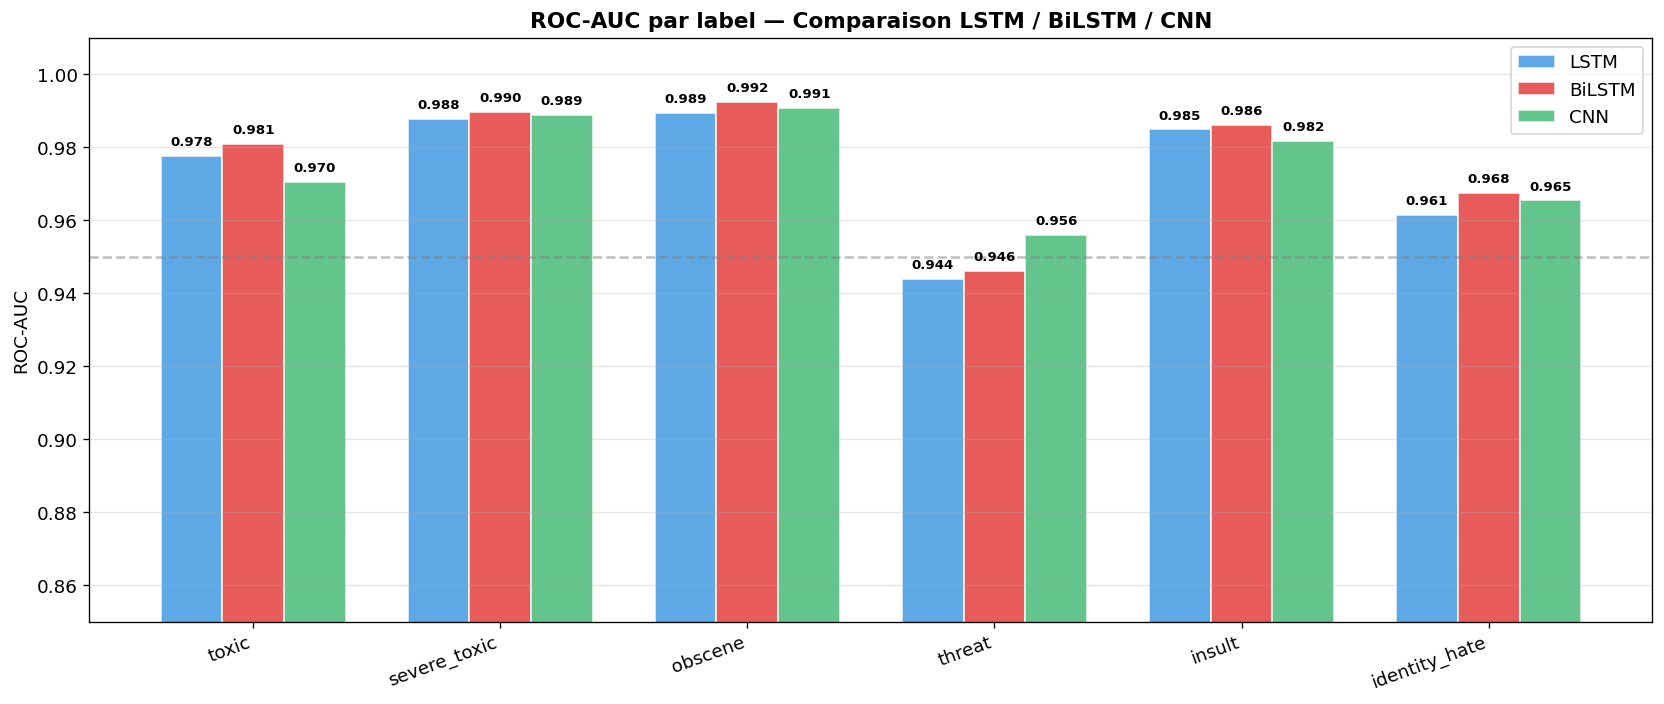

In [9]:
# AUC par label pour chaque modèle
auc_data = []
for name in models.keys():
    y_proba = preds[name]['proba']
    for i, label in enumerate(LABELS):
        auc_data.append({
            'Modèle': name, 'Label': label,
            'AUC': roc_auc_score(y_val[:, i], y_proba[:, i])
        })
df_auc = pd.DataFrame(auc_data)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(LABELS))
width = 0.25

for i, (name, color) in enumerate(COLORS.items()):
    vals = df_auc[df_auc['Modèle'] == name]['AUC'].values
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(LABELS, rotation=20, ha='right')
ax.set_ylim([0.85, 1.01])
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC par label — Comparaison LSTM / BiLSTM / CNN', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.95')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_auc_per_label.png'), dpi=150)
plt.show()

## 9. 🎨 Visualisation 4 — Graphique Radar

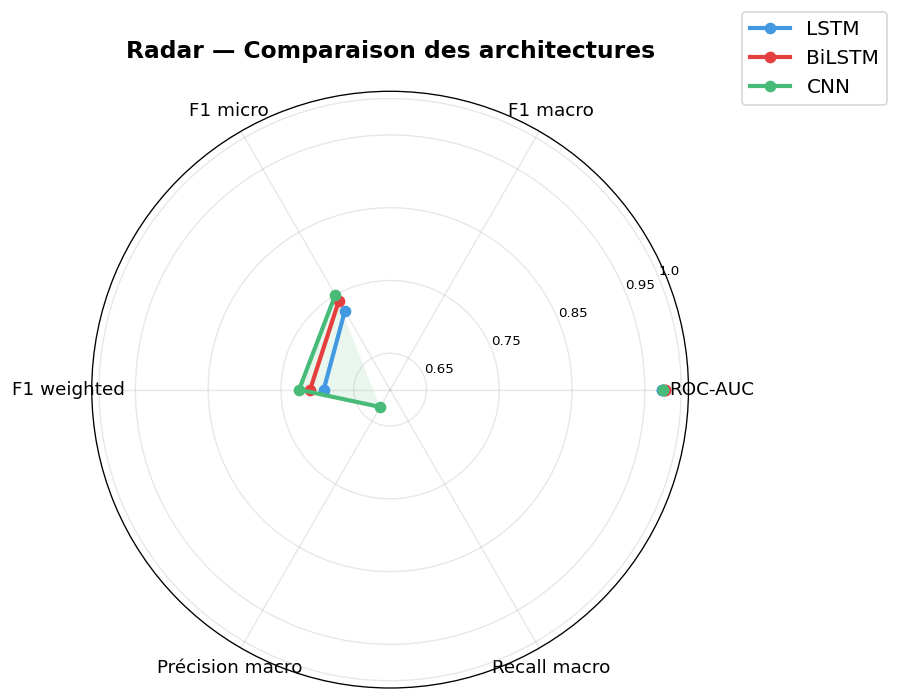

In [10]:
radar_metrics = ['ROC-AUC', 'F1 macro', 'F1 micro', 'F1 weighted', 'Précision macro', 'Recall macro']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, color in COLORS.items():
    values = [df_results.loc[name, m] for m in radar_metrics] + [df_results.loc[name, radar_metrics[0]]]
    ax.plot(angles, values, 'o-', lw=2.5, color=color, label=name)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0.6, 1.01)
ax.set_yticks([0.65, 0.75, 0.85, 0.95, 1.0])
ax.set_yticklabels(['0.65', '0.75', '0.85', '0.95', '1.0'], fontsize=8)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=12)
ax.set_title('Radar — Comparaison des architectures', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. 🎨 Visualisation 5 — F1 score par label et par modèle

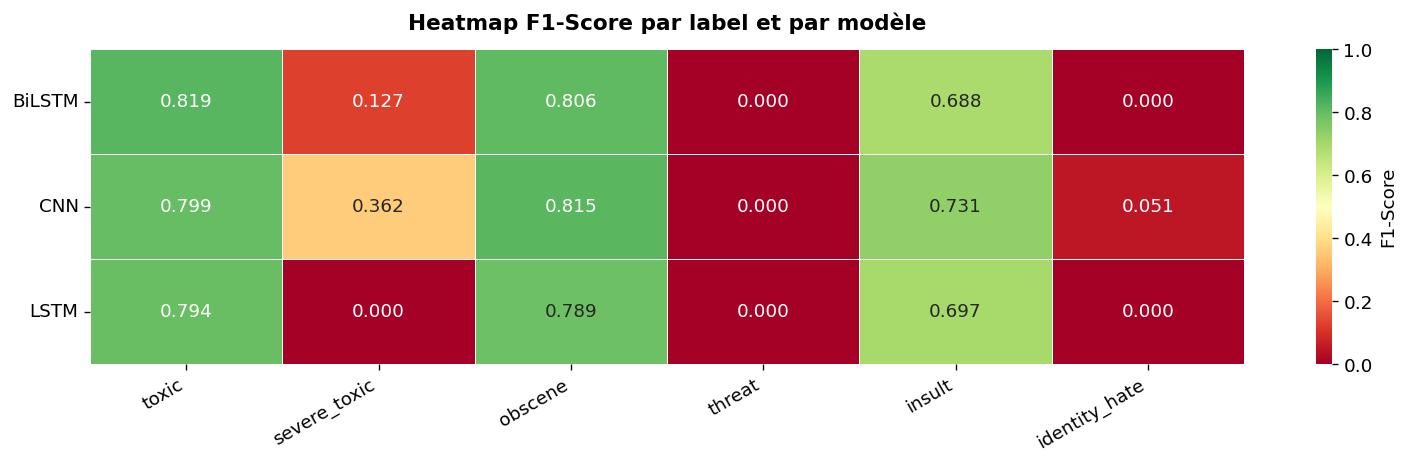

In [11]:
f1_data = []
for name in models.keys():
    y_pred = preds[name]['pred']
    for i, label in enumerate(LABELS):
        f1_data.append({
            'Modèle': name, 'Label': label,
            'F1': f1_score(y_val[:, i], y_pred[:, i], zero_division=0)
        })
df_f1 = pd.DataFrame(f1_data)

# Heatmap F1
pivot = df_f1.pivot(index='Modèle', columns='Label', values='F1')[LABELS]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'F1-Score'})
ax.set_title('Heatmap F1-Score par label et par modèle', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_f1_heatmap.png'), dpi=150)
plt.show()

## 11. ⚡ Visualisation 6 — Performance vs Vitesse

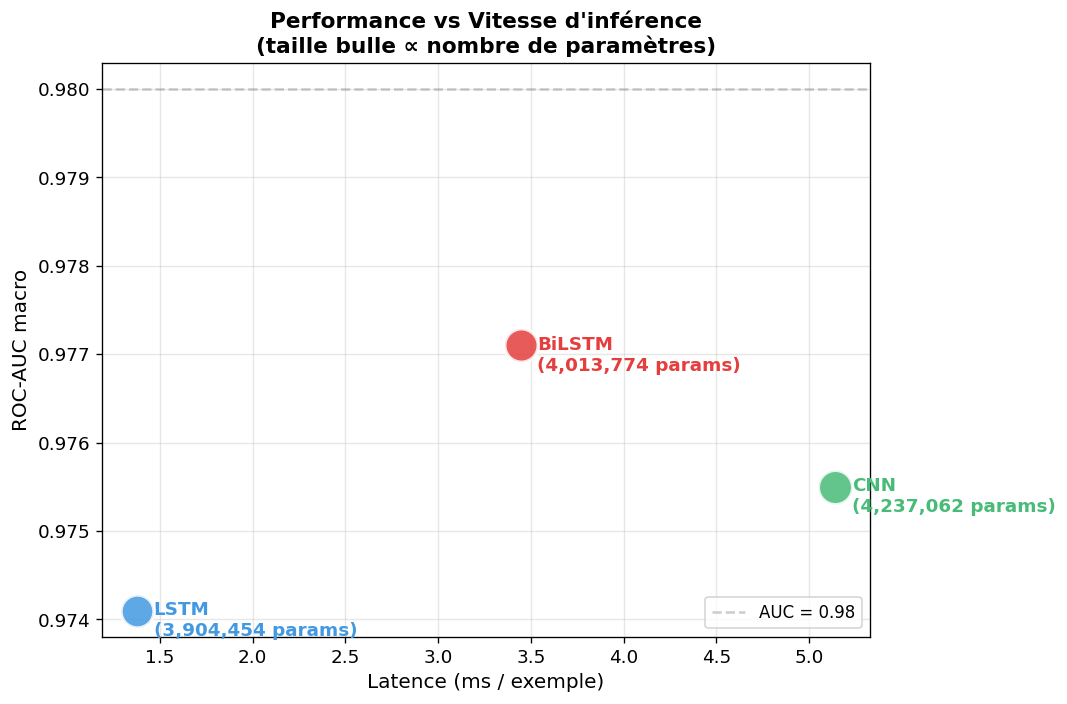

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, color in COLORS.items():
    auc_val     = df_results.loc[name, 'ROC-AUC']
    latency_val = df_results.loc[name, 'Latence (ms/ex)']
    n_params    = df_results.loc[name, 'Paramètres']
    size        = n_params / 10000  # taille proportionnelle au nombre de paramètres

    ax.scatter(latency_val, auc_val, s=size, color=color, alpha=0.85,
               edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(f'{name}\n({n_params:,} params)',
                xy=(latency_val, auc_val),
                xytext=(10, -15), textcoords='offset points',
                fontsize=11, fontweight='bold', color=color)

ax.set_xlabel('Latence (ms / exemple)', fontsize=12)
ax.set_ylabel('ROC-AUC macro', fontsize=12)
ax.set_title('Performance vs Vitesse d\'inférence\n(taille bulle ∝ nombre de paramètres)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Zones de qualité
ax.axhline(y=0.98, color='gray', linestyle='--', alpha=0.4, label='AUC = 0.98')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_perf_vs_speed.png'), dpi=150)
plt.show()

## 12. 🏆 Bilan & Recommandation finale

In [13]:
best_auc    = df_results['ROC-AUC'].idxmax()
best_f1     = df_results['F1 macro'].idxmax()
fastest     = df_results['Latence (ms/ex)'].idxmin()
fewest_params = df_results['Paramètres'].idxmin()

print('\n' + '█'*60)
print('  BILAN FINAL — RECOMMANDATIONS')
print('█'*60)
print()
print(f'  🥇 Meilleur ROC-AUC    : {best_auc}')
print(f'     → Score  : {df_results.loc[best_auc, "ROC-AUC"]:.4f}')
print()
print(f'  🎯 Meilleur F1 macro   : {best_f1}')
print(f'     → Score  : {df_results.loc[best_f1, "F1 macro"]:.4f}')
print()
print(f'  ⚡ Plus rapide         : {fastest}')
print(f'     → Latence : {df_results.loc[fastest, "Latence (ms/ex)"]:.3f} ms/ex')
print()
print(f'  💾 Moins de paramètres : {fewest_params}')
print(f'     → Params  : {df_results.loc[fewest_params, "Paramètres"]:,}')
print()
print('─'*60)
print('  CONSEIL D\'USAGE :')
print('  • Production haute précision → BiLSTM')
print('  • Temps réel / contrainte latence → CNN')
print('  • Compromis équilibré → LSTM')
print('─'*60)

# Sauvegarde finale
df_results.to_csv(os.path.join(RESULTS_DIR, 'final_comparison.csv'))
print('\n✅ Résultats sauvegardés → final_comparison.csv')
print('✅ Graphiques sauvegardés dans Drive')


████████████████████████████████████████████████████████████
  BILAN FINAL — RECOMMANDATIONS
████████████████████████████████████████████████████████████

  🥇 Meilleur ROC-AUC    : BiLSTM
     → Score  : 0.9771

  🎯 Meilleur F1 macro   : CNN
     → Score  : 0.4596

  ⚡ Plus rapide         : LSTM
     → Latence : 1.376 ms/ex

  💾 Moins de paramètres : LSTM
     → Params  : 3,904,454

────────────────────────────────────────────────────────────
  CONSEIL D'USAGE :
  • Production haute précision → BiLSTM
  • Temps réel / contrainte latence → CNN
  • Compromis équilibré → LSTM
────────────────────────────────────────────────────────────

✅ Résultats sauvegardés → final_comparison.csv
✅ Graphiques sauvegardés dans Drive


## 13. 🧪 Test sur des exemples personnalisés

In [16]:
# Teste les 3 modèles sur des phrases personnalisées
test_comments = [
    "You are an idiot and should go kill yourself",   # très toxique
    "I disagree with your political opinion",          # neutre
    "This is a great article, thanks for sharing!",   # positif
    "I hate you, you are an awfull person",  # haineux
    "The weather is nice today",                       # neutre
]


def predict_comments(comments, models_dict, tokenizer, max_len, threshold=0.5):
    """Prédit la toxicité de commentaires personnalisés."""
    def clean(t):
        t = str(t).lower()
        t = re.sub(r'[^a-z0-9\s!?.,]', ' ', t)
        return re.sub(r'\s+', ' ', t).strip()

    seqs = pad_sequences(
        tokenizer.texts_to_sequences([clean(c) for c in comments]),
        maxlen=max_len, padding='post', truncating='post'
    )

    print('\n' + '='*80)
    print('  PRÉDICTIONS SUR EXEMPLES PERSONNALISÉS')
    print('='*80)

    for i, comment in enumerate(comments):
        print(f'\n  [{i+1}] "{comment[:70]}"')
        print(f'  {"─"*70}')
        for name, model in models_dict.items():
            proba = model.predict(seqs[i:i+1], verbose=0)[0]
            detected = [LABELS[j] for j, p in enumerate(proba) if p >= threshold]
            max_label = LABELS[proba.argmax()]
            print(f'  {name:8s} | Max: {max_label:15s} ({proba.max():.3f}) | '
                  f'Détectés: {detected if detected else "Aucun"}')

predict_comments(test_comments, models, tokenizer, MAX_LEN)


  PRÉDICTIONS SUR EXEMPLES PERSONNALISÉS

  [1] "You are an idiot and should go kill yourself"
  ──────────────────────────────────────────────────────────────────────
  LSTM     | Max: toxic           (0.987) | Détectés: ['toxic', 'obscene', 'insult']
  BiLSTM   | Max: toxic           (0.988) | Détectés: ['toxic', 'obscene', 'insult']
  CNN      | Max: toxic           (0.993) | Détectés: ['toxic', 'obscene', 'insult']

  [2] "I disagree with your political opinion"
  ──────────────────────────────────────────────────────────────────────
  LSTM     | Max: toxic           (0.032) | Détectés: Aucun
  BiLSTM   | Max: toxic           (0.002) | Détectés: Aucun
  CNN      | Max: toxic           (0.000) | Détectés: Aucun

  [3] "This is a great article, thanks for sharing!"
  ──────────────────────────────────────────────────────────────────────
  LSTM     | Max: toxic           (0.024) | Détectés: Aucun
  BiLSTM   | Max: toxic           (0.001) | Détectés: Aucun
  CNN      | Max: toxic     